In [7]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="E9Pyxhe86Ve7S2UDXHPT")
project = rf.workspace("bugsai").project("skin-diseases-gynnb")
version = project.version(1)
dataset = version.download("yolov11")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Skin-Diseases-1 in yolov11:: 100%|██████████| 8848/8848 [00:01<00:00, 6084.24it/s]


In [8]:
!pip install ultralytics -q
import ultralytics
ultralytics.checks()

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.3/112.6 GB disk)


In [9]:
from ultralytics import YOLO
import os

# Define the path to the Roboflow-generated YAML file
yaml_path = os.path.join(dataset.location, "data.yaml")

# Load a pre-trained YOLOv11 model
# Use yolo11n.pt if the dataset uses bounding boxes, or yolo11n-seg.pt if it has masks
model = YOLO("yolo11n.pt")

# Train the model
results = model.train(
    data=yaml_path,
    epochs=10,
    imgsz=512,
    batch=16,
    device=0,
    workers=2,
    project="skin_lesion_project",
    name="roboflow_yolo_run"
)

Ultralytics 8.4.90 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Skin-Diseases-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=roboflow_yolo_run, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=


0: 512x512 (no detections), 4.3ms
1: 512x512 2 Eczemas, 4.3ms
2: 512x512 (no detections), 4.3ms
Speed: 3.0ms preprocess, 4.3ms inference, 1.9ms postprocess per image at shape (1, 3, 512, 512)
Results saved to /content/runs/detect/predict


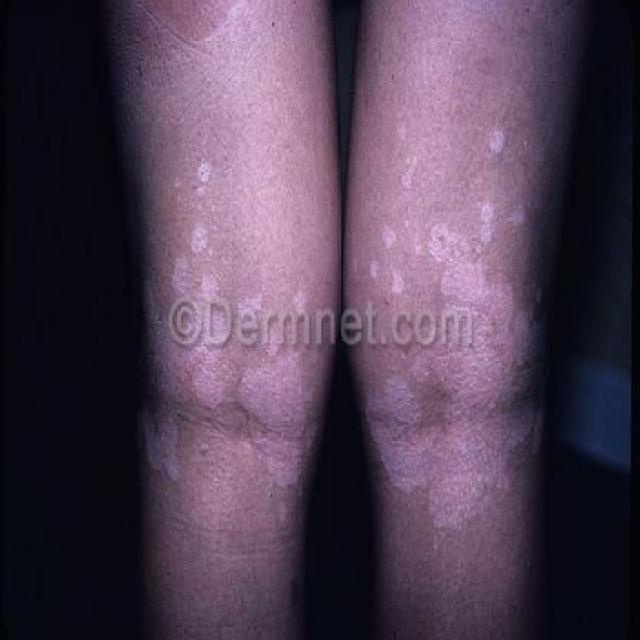

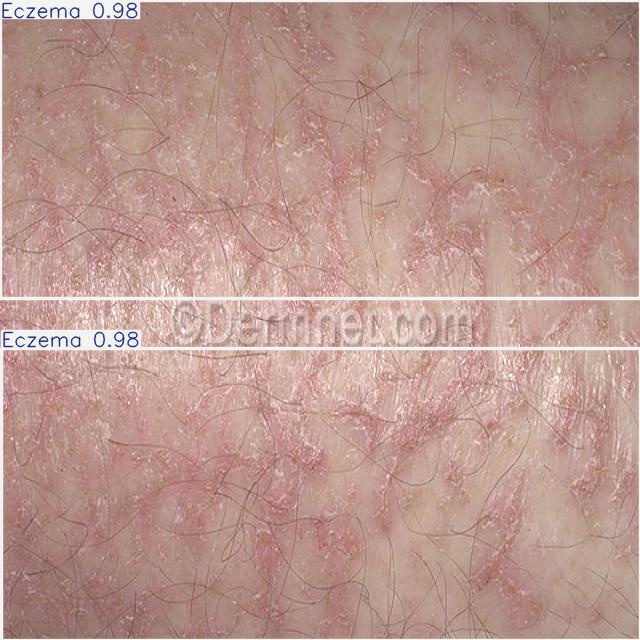

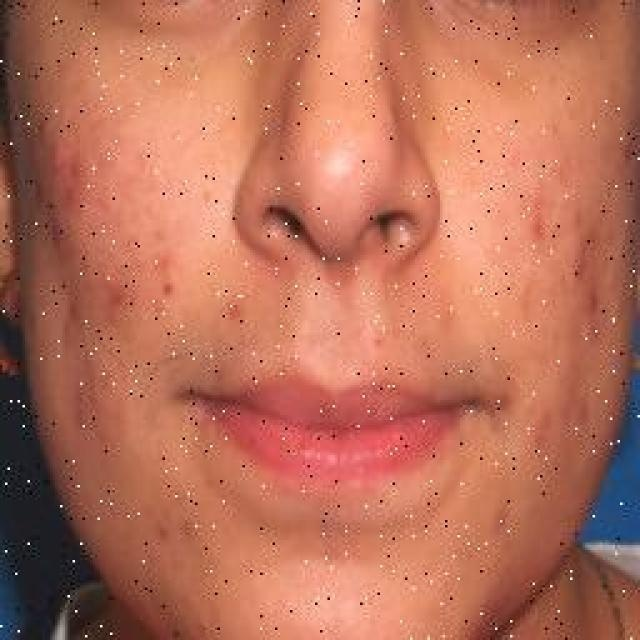

In [12]:
import glob
import os
from IPython.display import Image, display

# Grab a few images from the Roboflow test set
test_images = glob.glob(f"{dataset.location}/test/images/*.jpg")[:3]

# Run predictions
# The model will save the visually annotated images in the runs/detect directory
predictions = model.predict(source=test_images, save=True, conf=0.5)

# Display the results in the notebook
# FIX: Updated path to search inside runs/detect/
latest_predict_folder = max(glob.glob('runs/detect/predict*'), key=os.path.getmtime)

for img_path in glob.glob(f"{latest_predict_folder}/*.jpg"):
    display(Image(filename=img_path, width=400))

In [14]:
from google.colab import drive
import shutil
import glob
import os

# 1. Mount Google Drive
drive.mount('/content/drive')

# 2. Hunt for all 'best.pt' files anywhere in the Colab environment
weight_files = glob.glob('/content/**/weights/best.pt', recursive=True)

if not weight_files:
    print("❌ Error: No best.pt found. Did the training cell finish completely?")
else:
    # Grab the most recently modified best.pt (handling incremented folders like roboflow_yolo_run2)
    source_path = max(weight_files, key=os.path.getmtime)
    print(f"Found latest model weights at: {source_path}")

    # 3. Define your Google Drive destination path
    destination_path = "/content/drive/MyDrive/yolov11_roboflow_best.pt"

    # 4. Copy the file to Drive
    shutil.copy(source_path, destination_path)
    print(f"✅ Model successfully saved to Google Drive: {destination_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Found latest model weights at: /content/runs/detect/skin_lesion_project/roboflow_yolo_run/weights/best.pt
✅ Model successfully saved to Google Drive: /content/drive/MyDrive/yolov11_roboflow_best.pt
